# A *Paraxial / Slowly Varying Envelope* approximation for high frequency plane wave scattering a Taylor vortex

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from vortex2dscatter import Mach1HighFreqApprox, Mach1HighFreqApproxO1, Mach1Scatter2D

In [ ]:
def solve_high_frequency_case(case):
    full = Mach1Scatter2D(case["wavelength"]).init_mesh(5.0, case["full_mesh"]).add_taylor_vortex(case["mach"]).complete()
    high_o2 = Mach1HighFreqApprox(case["wavelength"]).init_mesh(5.0, case["env_mesh"]).add_taylor_vortex(case["mach"]).complete()
    high_o1 = Mach1HighFreqApproxO1(case["wavelength"]).init_mesh(5.0, case["env_mesh"]).add_taylor_vortex(case["mach"]).complete()

    full.solve(maxiter=case["maxiter"], tol=case["tol"])
    high_o2.solve(maxiter=case["maxiter"], tol=case["tol"])
    high_o1.solve(maxiter=case["maxiter"], tol=case["tol"])

    return dict(
        case=case,
        full=full,
        high_o2=high_o2,
        high_o1=high_o1,
        fields=[
            (full.x, full.y, full.sol_p / full.incident, "Full Mach-one"),
            (high_o2.x, high_o2.y, high_o2.envelope_scattered, r"$\mathcal{O}(k^2)$ envelope"),
            (high_o1.x, high_o1.y, high_o1.envelope_scattered, r"$\mathcal{O}(k)$ envelope"),
        ],
    )


cases = [
    dict(name="lambda_1_over_8", wavelength=1/8, mach=0.1, full_mesh=640, env_mesh=200, vmax=3.0, maxiter=10, tol=1e-20),
    dict(name="lambda_1_over_16", wavelength=1/16, mach=0.1, full_mesh=1280, env_mesh=200, vmax=5.0, maxiter=10, tol=1e-20),
]

results = [solve_high_frequency_case(case) for case in cases]


## Field comparison

For each case, the top row shows the real part and the bottom row shows the imaginary part. The three columns correspond to the full Mach-one solution, the leading high-frequency envelope equation, and the next-order corrected envelope equation.

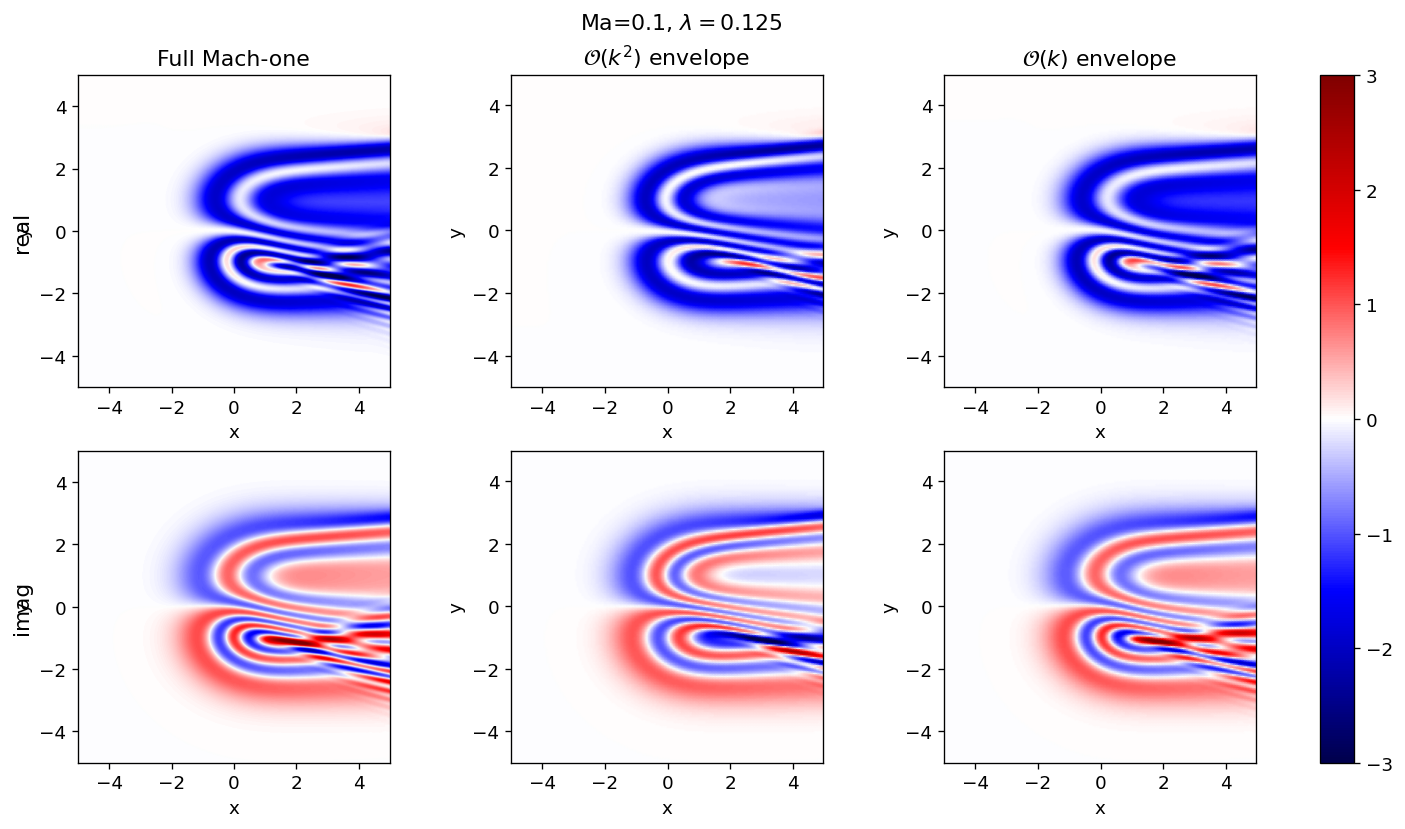

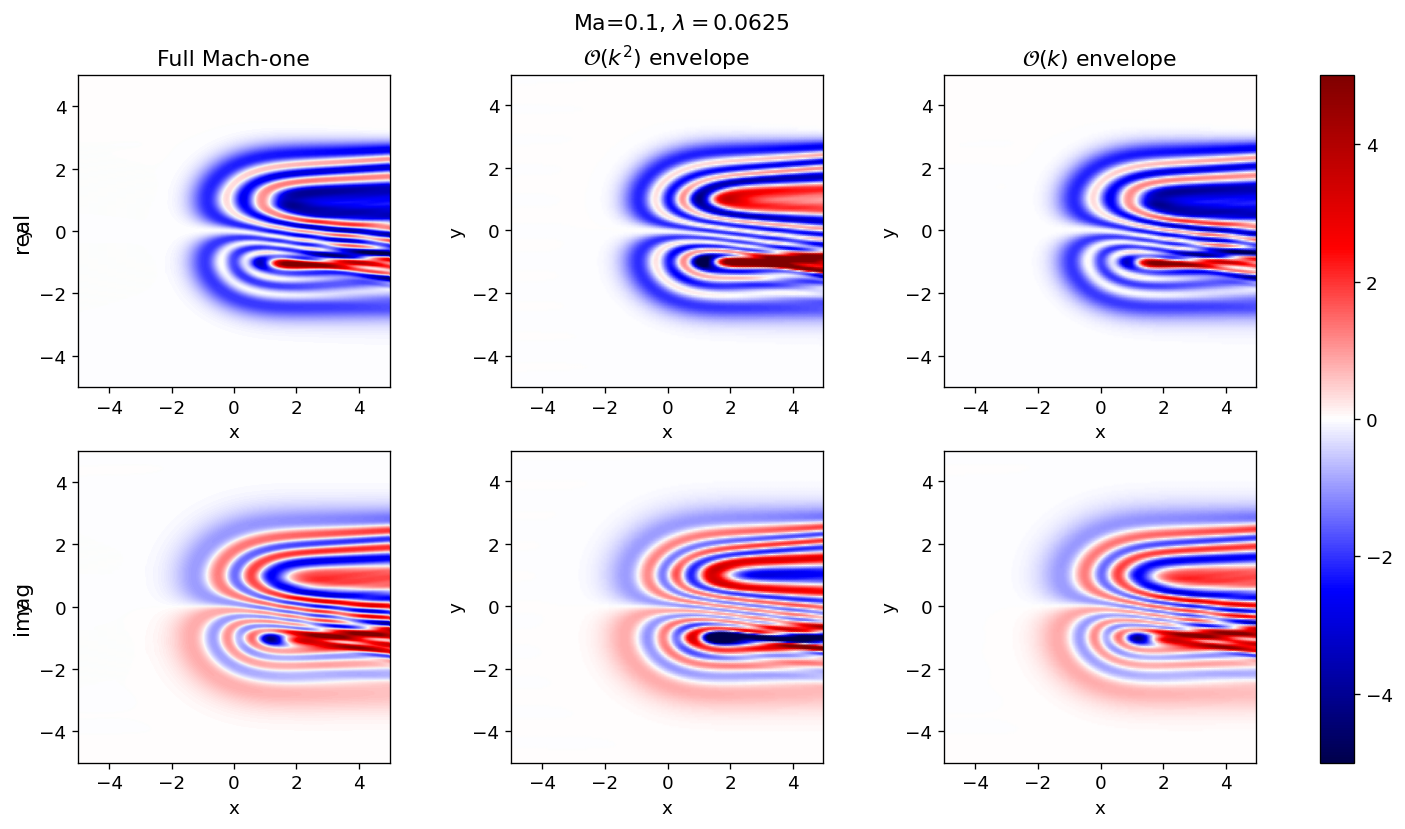

In [3]:
def plot_high_frequency_result(result):
    case = result["case"]
    fig, axs = plt.subplots(2, 3, figsize=(12, 6.8), constrained_layout=True)
    common = dict(cmap="seismic", shading="gouraud", vmin=-case["vmax"], vmax=case["vmax"], rasterized=True, edgecolors="none")

    for j, (x, y, z, title) in enumerate(result["fields"]):
        im = axs[0, j].pcolormesh(x, y, z.real, **common)
        axs[1, j].pcolormesh(x, y, z.imag, **common)
        axs[0, j].set_title(title)
        for ax in axs[:, j]:
            ax.set_aspect("equal")
            ax.set_xlabel("x")
            ax.set_ylabel("y")

    axs[0, 0].text(-0.18, 0.5, "real", transform=axs[0, 0].transAxes, rotation=90, va="center", ha="center", fontsize=13)
    axs[1, 0].text(-0.18, 0.5, "imag", transform=axs[1, 0].transAxes, rotation=90, va="center", ha="center", fontsize=13)
    fig.suptitle(rf"Ma={case['mach']}, $\lambda={case['wavelength']}$")
    cbar = fig.colorbar(im, ax=axs, orientation="vertical")
    cbar.solids.set_rasterized(True)
    return fig


for result in results:
    plot_high_frequency_result(result)
